In [78]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

In [ ]:
# scale data
def scale(X, X_min, X_max):
    return (X - X_min)/(X_max-X_min)

NUM_CLASSES = 3

epochs = 1000
batch_size = 32
num_neurons = 10
seed = 10

np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
histories = {}

In [ ]:
#read train data
train_input = np.genfromtxt('ctg_data_cleaned.csv', delimiter= ',')
x, y = train_input[1:, :21], train_input[1:,-1].astype(int)
x = scale(x, np.min(x, axis=0), np.max(x, axis=0))
y = y-1

In [ ]:
# Divide the dataset into training and test data
trainX, testX, trainY, testY = train_test_split(x, y, test_size=0.3, train_size=0.7, random_state=42)

In [65]:
'''Applying 5-fold cross-vaidation on the training dataset
   Further splits training dataset into training and validation'''
kf = KFold(n_splits=5, shuffle=False, random_state=None)
i=1
for training, test in kf.split(trainX):
    exec('train_X_{} = trainX[training]'.format(i))
    exec('print(v_X_{}.shape)'.format(i))
    exec('v_X_{} = trainX[test]'.format(i))
    i+=1
i=1
for training, test in kf.split(trainY):
    exec('train_Y_{} = trainY[training]'.format(i))
    exec('v_Y_{} = trainY[test]'.format(i))
    i+=1

(298, 21)
(298, 21)
(298, 21)
(297, 21)
(297, 21)


In [ ]:
# create the models
model_1 = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(3, activation='softmax')
])

model_2 = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(3, activation='softmax')
])

model_3 = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(3, activation='softmax')
])

model_4 = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(3, activation='softmax')
])

model_5 = keras.Sequential([
    keras.layers.Dense(input_shape=(21,), units=num_neurons, activation='relu', kernel_regularizer=l2(0.000001)),
    keras.layers.Dense(3, activation='softmax')
])

In [ ]:
opt = SGD(lr=0.01)

In [ ]:
model_1.compile(optimizer=opt,
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_2.compile(optimizer=opt,
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_3.compile(optimizer=opt,
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_4.compile(optimizer=opt,
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_5.compile(optimizer=opt,
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [81]:
# train the model
histories['split1'] =model_1.fit(train_X_1, train_Y_1,
                                        validation_data = (v_X_1, v_Y_1),
                                        epochs=epochs,
                                        verbose = 0,
                                        batch_size=batch_size)
print('1/5')

histories['split2'] =model_2.fit(train_X_2, train_Y_2,
                                        validation_data = (v_X_2, v_Y_2),
                                        epochs=epochs,
                                        verbose = 0,
                                        batch_size=batch_size)
print('2/5')

histories['split3'] =model_3.fit(train_X_3, train_Y_3,
                                        validation_data = (v_X_3, v_Y_3),
                                        epochs=epochs,
                                        verbose = 0,
                                        batch_size=batch_size)
print('3/5')

histories['split4'] =model_4.fit(train_X_4, train_Y_4,
                                        validation_data = (v_X_4, v_Y_4),
                                        epochs=epochs,
                                        verbose = 0,
                                        batch_size=batch_size)
print('4/5')

histories['split5'] =model_5.fit(train_X_5, train_Y_5,
                                        validation_data = (v_X_5, v_Y_5),
                                        epochs=epochs,
                                        verbose = 0,
                                        batch_size=batch_size)
print('Training complete')


1/5
2/5
3/5
4/5
Training complete


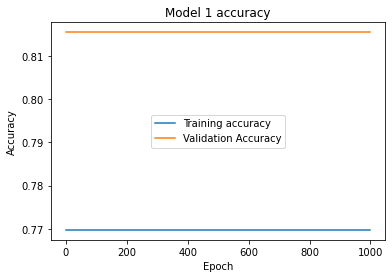

In [86]:
# plot learning curves
plt.plot(histories['split1'].history['accuracy'])
plt.plot(histories['split1'].history['val_accuracy'])
plt.title('Model 1 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training accuracy', 'Validation Accuracy'], loc='center')
plt.show()

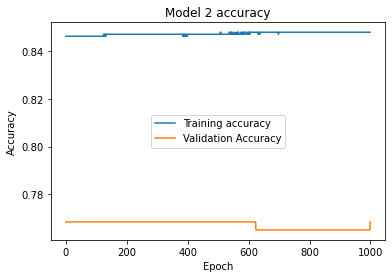

In [87]:
plt.plot(histories['split2'].history['accuracy'])
plt.plot(histories['split2'].history['val_accuracy'])
plt.title('Model 2 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training accuracy', 'Validation Accuracy'], loc='center')
plt.show()

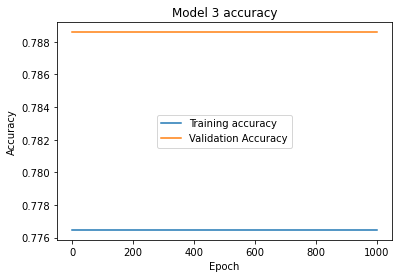

In [88]:
plt.plot(histories['split3'].history['accuracy'])
plt.plot(histories['split3'].history['val_accuracy'])
plt.title('Model 3 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training accuracy', 'Validation Accuracy'], loc='center')
plt.show()

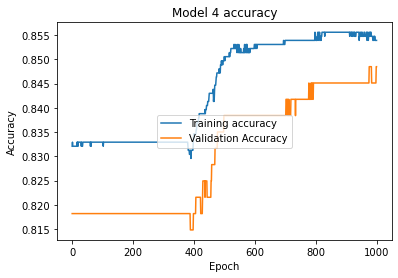

In [90]:
plt.plot(histories['split4'].history['accuracy'])
plt.plot(histories['split4'].history['val_accuracy'])
plt.title('Model 4 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training accuracy', 'Validation Accuracy'], loc='center')
plt.show()

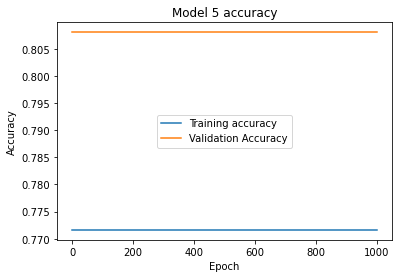

In [91]:
plt.plot(histories['split5'].history['accuracy'])
plt.plot(histories['split5'].history['val_accuracy'])
plt.title('Model 5 accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training accuracy', 'Validation Accuracy'], loc='center')
plt.show()

In [93]:
results = model_4.evaluate(testX, testY)
print(results)

638/638 [==============================] - 0s 25us/sample - loss: 0.7223 - accuracy: 0.8260
[0.7222986845387187, 0.8260188]
